In [1]:
import networkx as nx
import pandas as pd
import json
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from cup_classes import Iteration
from hcgcr_gather_data import hcgcr_data
from cup_main import color_update_propagation
from cup_functions import update_queue_cup, update_queue_cas, update_queue_cor

base_path = PROJECT_ROOT / "experiment" / "test_graphs"

q_func_names = ["cor", "cas", "cup"]
update_functions = [
    update_queue_cor,
    update_queue_cas,
    update_queue_cup,
]


In [2]:
def nxgraph(n, edges):
    G = nx.Graph()
    G.add_edges_from([tuple(e) for e in edges])
    G.add_nodes_from(range(int(n)))
    return G

def restore_dict_values(hash_dict):
    # hash_dict: {"hash": {"color": int, "orbit": list-or-set}, ...}
    output = {}
    for hash, val in hash_dict.items():
        color = int(val["color"])
        orbit = val.get("orbit")
        if isinstance(orbit, list):  # JSON-serialized set
            orbit = set(orbit)
        output[hash] = {"color": color, "orbit": orbit}
    return output

def unpack(name):
    df = pd.read_csv(base_path / name)
    # dataframe with two columns: G - the graph, iterations with list of iteration objects
    for col in ["graph", "coloring", "hash_dict"]:
        df[col] = df[col].apply(json.loads)
    graphs = []
    iterations = []
    for _, row in df.iterrows():
        graphs.append(nxgraph(row["n"], row["graph"]))
        iter = []
        for coloring_dict, hash_dict_from_json in zip(row["coloring"], row["hash_dict"]):
            coloring = pd.DataFrame(coloring_dict)
            hash_dict = restore_dict_values(hash_dict_from_json)
            iter.append(Iteration(coloring, hash_dict))
        iterations.append(iter)
    return pd.DataFrame({"graph": graphs, "iterations": iterations})
df_all = unpack("random_trees.csv")

None


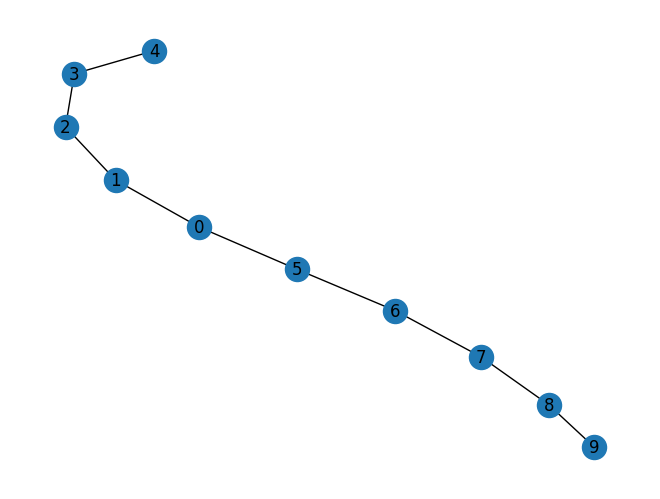

In [3]:
G = nx.random_unlabeled_tree(10)
old_iterations = hcgcr_data(G)
print(nx.draw(G, with_labels=True))

In [4]:
for i in range(len(old_iterations)):
    print(f"Iteration {i}: {old_iterations[i].color}")

Iteration 0: [1 1 1 1 2 1 1 1 1 2]
Iteration 1: [1 1 1 2 3 1 1 1 2 3]
Iteration 2: [1 1 2 3 4 1 1 2 3 4]
Iteration 3: [1 2 3 4 5 1 2 3 4 5]
Iteration 4: [1 2 3 4 5 1 2 3 4 5]


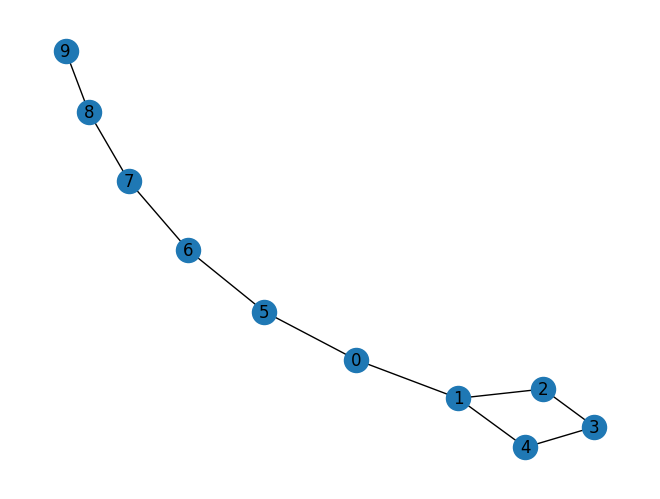

In [5]:
G_upd = G.copy()
G_upd.add_edge(4,1)
nx.draw(G_upd, with_labels=True)

In [12]:
coloring_upd_list = color_update_propagation(G_upd, {1,4}, old_iterations, update_queue_cor)

In [13]:
print(coloring_upd_list)

[array([1, 3, 1, 1, 1, 1, 1, 1, 1, 2]), array([4, 5, 4, 1, 4, 1, 1, 1, 2, 3]), array([5, 6, 5, 7, 5, 8, 1, 2, 3, 4]), array([ 6,  7,  8,  9,  8, 10, 11,  3,  4,  5]), array([ 6,  7,  8,  9,  8, 10, 11, 12,  4,  5])]
